Libraries imported successfully.
Sentiment Data Loaded: 2644 rows.
Sentiment Date Range: 2018-02-01 00:00:00 to 2025-05-02 00:00:00
Trader Data Loaded: 88466 rows.
Trader Date Range: 2023-05-01 00:00:00 to 2025-05-01 00:00:00

Merge Complete! Total trades aligned with sentiment: 88460


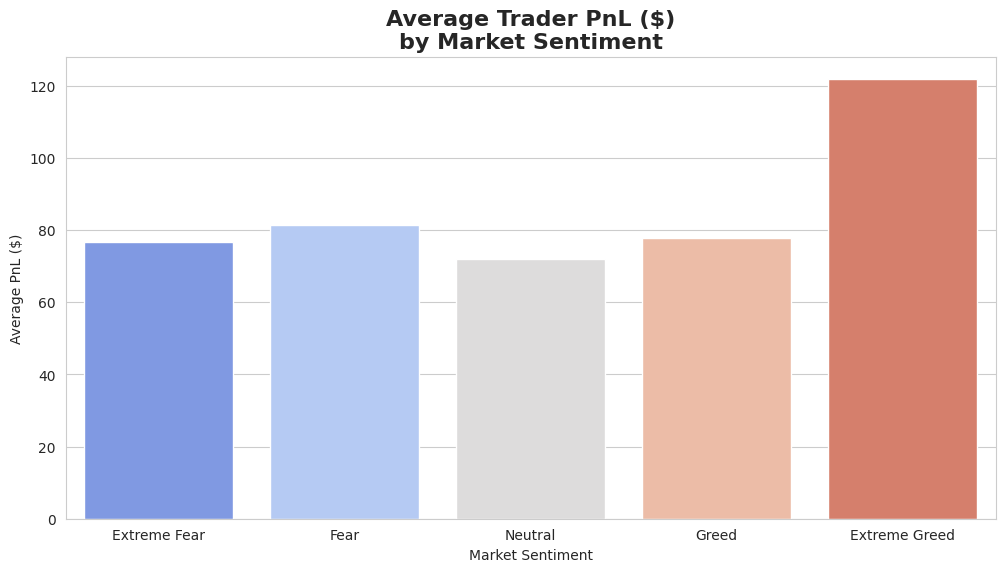

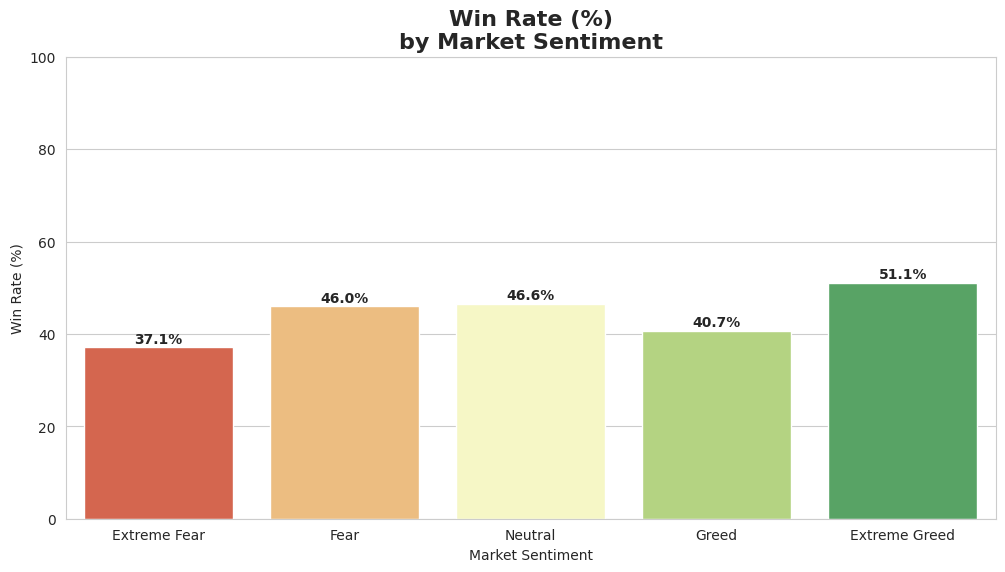

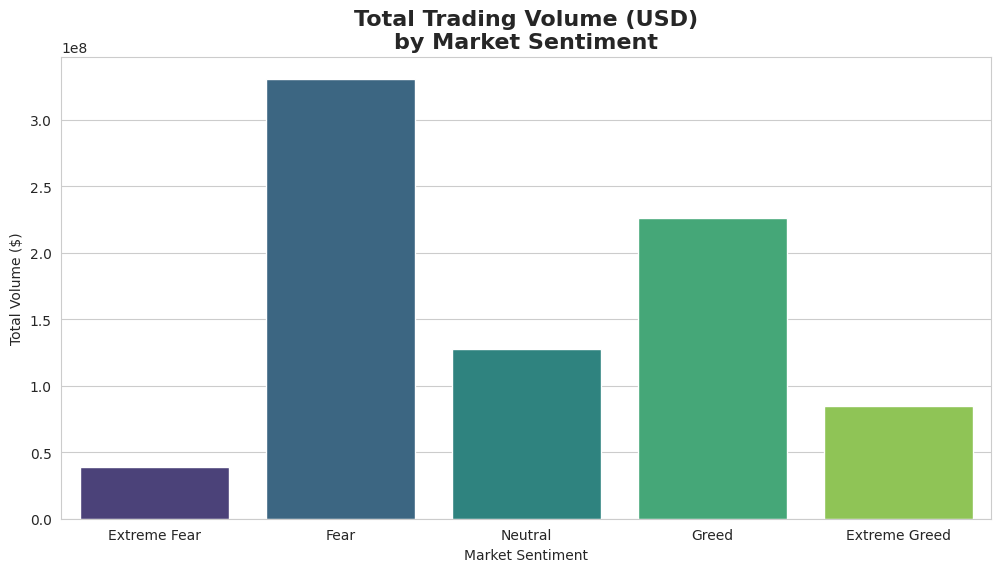

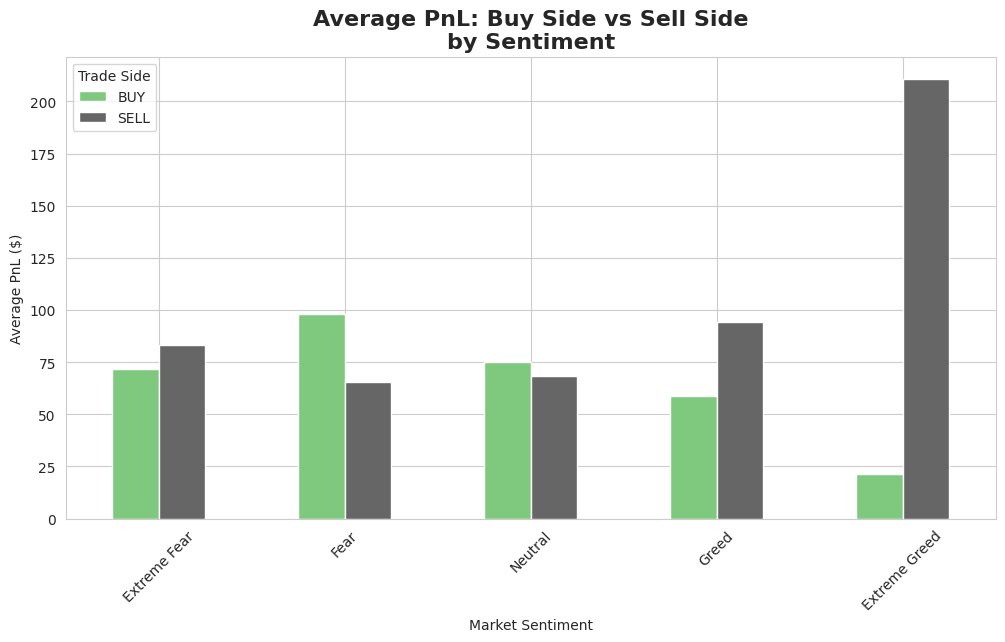

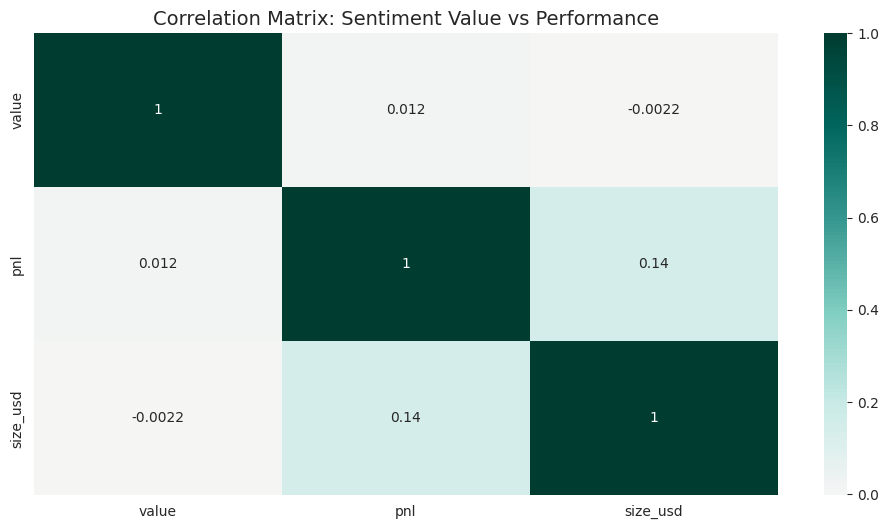


STRATEGIC INSIGHTS REPORT

1. Most Profitable Sentiment: Extreme Greed
   Average Profit per trade: $121.90

2. Highest Win Rate Sentiment: Extreme Greed
   Win Rate: 51.06%

3. Top 5 Most Profitable Accounts:
account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
Name: pnl, dtype: float64

4. Where Top Traders Make Their Money:
classification
Fear             2.200192e+06
Greed            1.201510e+06
Extreme Greed    1.189307e+06
Neutral          1.024620e+06
Extreme Fear     3.251103e+05
Name: pnl, dtype: float64


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully.")


def load_and_clean_data():
    try:
        # 1. Load Sentiment Data
        df_sentiment = pd.read_csv('/content/fear_greed_index.csv')

        df_sentiment.columns = df_sentiment.columns.str.strip().str.lower()

        df_sentiment['date'] = pd.to_datetime(df_sentiment['date'], errors='coerce')

        df_sentiment = df_sentiment.dropna(subset=['date'])

        df_sentiment = df_sentiment.sort_values('date')

        print(f"Sentiment Data Loaded: {df_sentiment.shape[0]} rows.")
        print(f"Sentiment Date Range: {df_sentiment['date'].min()} to {df_sentiment['date'].max()}")

        # 2. Load Trader Data
        df_trades = pd.read_csv('/content/historical_data.csv')

        df_trades.columns = df_trades.columns.str.strip().str.lower()

        df_trades = df_trades.rename(columns={
            'timestamp ist': 'trade_time',
            'closed pnl': 'pnl',
            'size usd': 'size_usd'
        })

        df_trades['date'] = pd.to_datetime(df_trades['trade_time'], format='%d-%m-%Y %H:%M', errors='coerce').dt.date
        df_trades['date'] = pd.to_datetime(df_trades['date'])

        df_trades = df_trades.dropna(subset=['date'])

        print(f"Trader Data Loaded: {df_trades.shape[0]} rows.")
        print(f"Trader Date Range: {df_trades['date'].min()} to {df_trades['date'].max()}")

        return df_sentiment, df_trades

    except FileNotFoundError as e:
        print(f"ERROR: {e}. Please make sure CSV files are uploaded.")
        return None, None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None, None

# Load the data
df_sentiment, df_trades = load_and_clean_data()


if df_sentiment is not None and df_trades is not None:
    merged_df = pd.merge(df_trades, df_sentiment[['date', 'value', 'classification']],
                         on='date', how='inner')

    print(f"\nMerge Complete! Total trades aligned with sentiment: {merged_df.shape[0]}")

    if merged_df.shape[0] == 0:
        print("\nWARNING: No overlapping dates found between the datasets.")
        print("This happens if the Sentiment file ends in 2021 but Trades start in 2024.")
        print("ACTION: Download the LATEST '/content/fear_greed_index.csv' from the provided Google Drive link.")
    else:
        merged_df['classification'] = merged_df['classification'].str.strip().str.title()

        sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

        merged_df = merged_df[merged_df['classification'].isin(sentiment_order)]


if not merged_df.empty:

    plt.figure()
    avg_pnl = merged_df.groupby('classification')['pnl'].mean().reindex(sentiment_order)
    sns.barplot(x=avg_pnl.index, y=avg_pnl.values, palette='coolwarm')
    plt.title('Average Trader PnL ($)\nby Market Sentiment', fontsize=16, fontweight='bold')
    plt.ylabel('Average PnL ($)')
    plt.xlabel('Market Sentiment')
    plt.show()

    merged_df['win'] = merged_df['pnl'] > 0
    win_rate = merged_df.groupby('classification')['win'].mean().reindex(sentiment_order) * 100

    plt.figure()
    sns.barplot(x=win_rate.index, y=win_rate.values, palette='RdYlGn')
    plt.title('Win Rate (%)\nby Market Sentiment', fontsize=16, fontweight='bold')
    plt.ylabel('Win Rate (%)')
    plt.xlabel('Market Sentiment')
    plt.ylim(0, 100)
    for i, v in enumerate(win_rate.values):
        plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')
    plt.show()

    volume_by_sentiment = merged_df.groupby('classification')['size_usd'].sum().reindex(sentiment_order)

    plt.figure()
    sns.barplot(x=volume_by_sentiment.index, y=volume_by_sentiment.values, palette='viridis')
    plt.title('Total Trading Volume (USD)\nby Market Sentiment', fontsize=16, fontweight='bold')
    plt.ylabel('Total Volume ($)')
    plt.xlabel('Market Sentiment')
    plt.show()

    side_analysis = merged_df.groupby(['classification', 'side'])['pnl'].mean().unstack()
    side_analysis = side_analysis.reindex(sentiment_order)

    side_analysis.plot(kind='bar', colormap='Accent')
    plt.title('Average PnL: Buy Side vs Sell Side\nby Sentiment', fontsize=16, fontweight='bold')
    plt.ylabel('Average PnL ($)')
    plt.xlabel('Market Sentiment')
    plt.xticks(rotation=45)
    plt.legend(title='Trade Side')
    plt.show()

    plt.figure()
    corr = merged_df[['value', 'pnl', 'size_usd']].corr()
    sns.heatmap(corr, annot=True, cmap='BrBG', center=0)
    plt.title('Correlation Matrix: Sentiment Value vs Performance', fontsize=14)
    plt.show()


if not merged_df.empty:
    print("\n" + "="*50)
    print("STRATEGIC INSIGHTS REPORT")
    print("="*50)

    best_sentiment = avg_pnl.idxmax()
    print(f"\n1. Most Profitable Sentiment: {best_sentiment}")
    print(f"   Average Profit per trade: ${avg_pnl.max():.2f}")

    safest_sentiment = win_rate.idxmax()
    print(f"\n2. Highest Win Rate Sentiment: {safest_sentiment}")
    print(f"   Win Rate: {win_rate.max():.2f}%")

    top_traders = merged_df.groupby('account')['pnl'].sum().sort_values(ascending=False).head(5)
    print("\n3. Top 5 Most Profitable Accounts:")
    print(top_traders)

    top_trader_df = merged_df[merged_df['account'].isin(top_traders.index)]
    top_trader_preference = top_traders = top_trader_df.groupby('classification')['pnl'].sum()

    print("\n4. Where Top Traders Make Their Money:")
    print(top_trader_preference.sort_values(ascending=False))

else:
    print("\nAnalysis could not run because datasets do not overlap in time.")